In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("..")

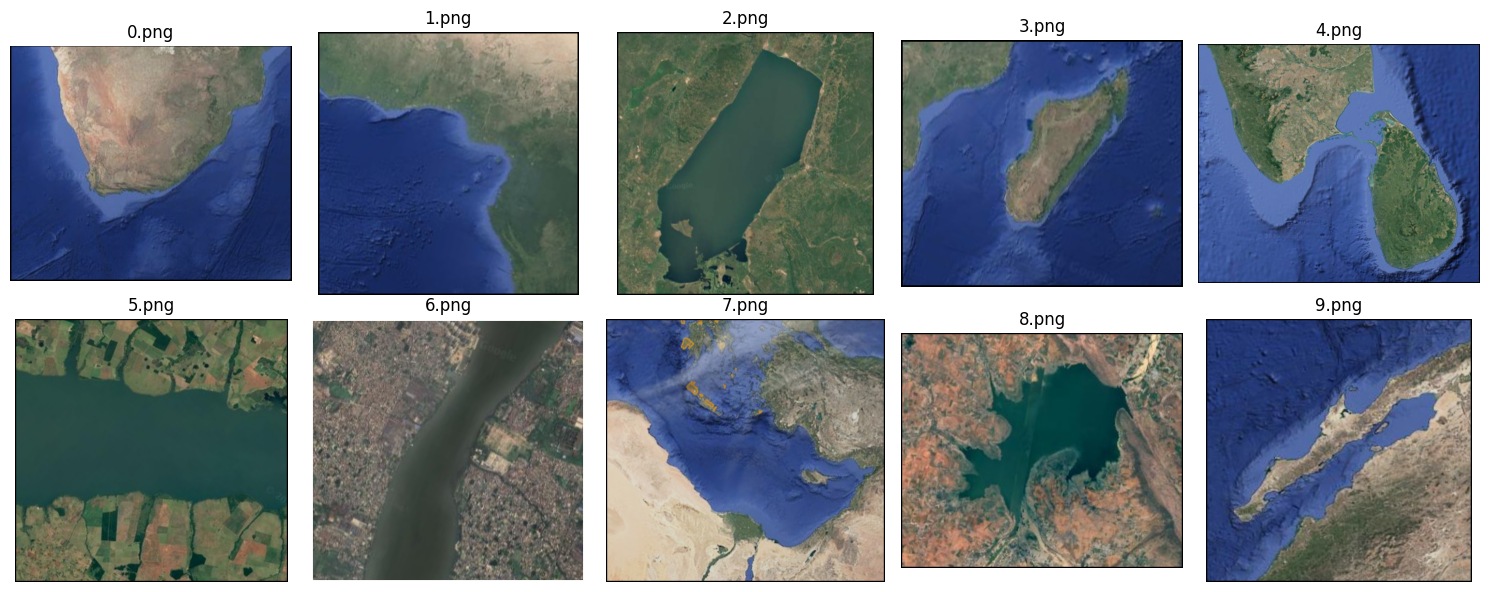

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    path = "data/testcases/" + str(i) + ".png"
    image = cv2.imread(path)
    
    axes[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[i].axis('off')
    axes[i].set_title(f"{i}.png")

plt.tight_layout()
plt.show()

In [4]:
from main import run_pipeline

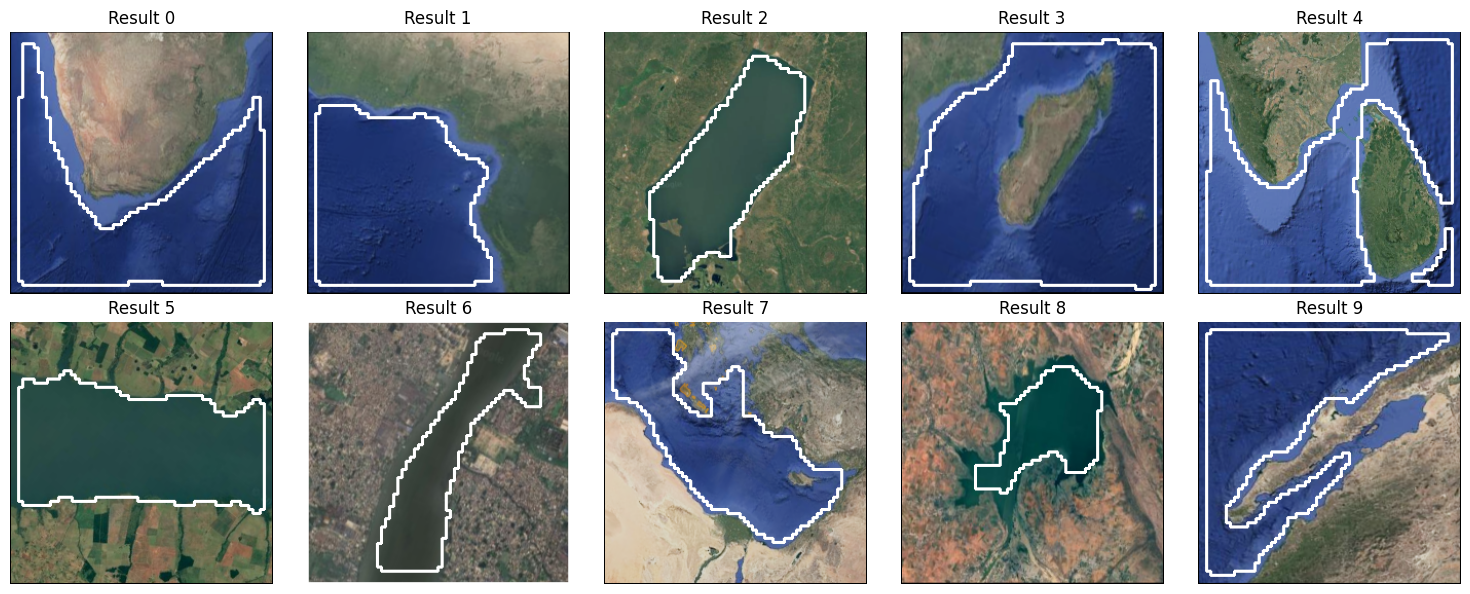

In [5]:
results = []

for i in range(10):
    path = "data/testcases/" + str(i) + ".png"
    original, result = run_pipeline(path)
    results.append(result)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(cv2.cvtColor(results[i], cv2.COLOR_BGR2RGB))
    axes[i].axis('off')
    axes[i].set_title(f"Result {i}")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

def extract_predicted_boundary_mask(result_image):
    gray = cv2.cvtColor(result_image, cv2.COLOR_BGR2GRAY)
    mask = (gray >= 255).astype(np.uint8)

    kernel = np.ones((2,2), np.uint8)
    mask = cv2.erode(mask, kernel)

    return mask

In [8]:
scores = []

for i in range(10):

    pred_img = results[i]
    pred_mask = extract_predicted_boundary_mask(pred_img)

    gt = cv2.imread(f"data/ground_truth_masks/{i}.png", 0)
    gt = cv2.resize(gt, (256,256))

    gt_mask = (gt > 10).astype(np.uint8)

    kernel = np.ones((3,3), np.uint8)
    gt_mask = cv2.dilate(gt_mask, kernel)

    intersection = np.sum(pred_mask * gt_mask)
    total_pred = np.sum(pred_mask)

    score = 0 if total_pred == 0 else intersection / total_pred

    print(f"Image {i} Score:", round(score,4))
    scores.append(score)

print("Average Boundary Score:", round(sum(scores)/len(scores),4))

Image 0 Score: 0.378
Image 1 Score: 0.5192
Image 2 Score: 0.9731
Image 3 Score: 0.2115
Image 4 Score: 0.6482
Image 5 Score: 0.84
Image 6 Score: 0.5936
Image 7 Score: 0.744
Image 8 Score: 0.727
Image 9 Score: 0.5862
Average Boundary Score: 0.6221
